In [ ]:
# An example of adapting the code for HW1P2 to our project
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
import numpy as np
from sklearn.datasets import load_iris
from sklearn.datasets import fetch_california_housing
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.neighbors import NearestNeighbors

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.losses import categorical_crossentropy
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import load_model

import matplotlib.pyplot as plt


In [ ]:
dataset_name = 'mnist'
# load dataset
import tensorflow as tf
import numpy as np
from sklearn.datasets import load_iris

def load_dataset(name):
    name = name.lower()

    if name == "iris":
        iris = load_iris()
        X = iris.data.astype("float32")
        y = iris.target.astype("int32")
        num_classes = 3

    elif name == "mnist":
        (X, y), _ = tf.keras.datasets.mnist.load_data()
        X = X.astype("float32") / 255.0
        X = X.reshape((X.shape[0], -1))  # flatten
        num_classes = 10

    elif name == "cifar10":
        (X, y), _ = tf.keras.datasets.cifar10.load_data()
        X = X.astype("float32") / 255.0
        X = X.reshape((X.shape[0], -1))  # flatten
        y = y.squeeze().astype("int32")
        num_classes = 10

    elif name == 'california_housing':
        data = fetch_california_housing()
        X = data.data.astype("float32")
        y = pd.qcut(data.target, q=3, labels=range(3)).astype(int)
        num_classes = 3

    elif name == 'wine':
        data = load_wine()
        X = data.data.astype("float32")
        y = data.target.astype("int32")
        num_classes = 3

    else:
        raise ValueError("Dataset must be one of: 'iris', 'mnist', 'cifar10'.")

    num_features = X.shape[1]

    # Convert labels → one-hot
    y = tf.keras.utils.to_categorical(y, num_classes=num_classes)

    # Create tf.data.Dataset
    # ds = tf.data.Dataset.from_tensor_slices((X, y))

    return X, y, num_features, num_classes


X,y,num_features, num_classes = load_dataset(dataset_name)
print(X.shape)
# split train/test data sets (70/30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 784)


In [ ]:
# use the MinMaxScaler to convert all features
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
def binary_entropy(p):
    p = tf.clip_by_value(p, 1e-7, 1 - 1e-7)
    return -p * tf.math.log(p) - (1 - p) * tf.math.log(1 - p)

def custom_Lk_loss(y_true, y_pred):
    # Standard CE
    ce = tf.keras.losses.categorical_crossentropy

    # penalty (h(0.5))
    penalty = 1.0

    # decide whether it is counterfactual (by checking whether there is 0.51)
    is_cca = tf.reduce_any(tf.equal(y_true, 0.51), axis=1)  # shape [batch]

    # get the probability on a certain idx
    idx = tf.argmax(y_true, axis=1, output_type=tf.int32)
    idx_onehot = tf.one_hot(idx, depth=tf.shape(y_true)[1])
    true_pred_prob = tf.reduce_sum(idx_onehot * y_pred, axis=1)

    # Condition：CCA sample AND true prob <= 0.5
    penalize_mask = tf.logical_and(is_cca, true_pred_prob <= 0.5)
    penalize_mask_f = tf.cast(penalize_mask, tf.float32)

    # modified loss
    loss = ce(y_true, y_pred) + penalize_mask_f * penalty

    return loss

In [ ]:
use_saved_model = False # if true, load saved model instead of training again

def train_model_and_save(X_train, y_train, model_name, dataset_name, num_features, num_classes, use_Lk=False):
    # Train a small neural network
    if dataset_name == 'iris':
      if model_name == 'model_orginal.keras':
          model = Sequential([
              keras.Input(shape=(X_train.shape[1],)),
              # Hidden Layer 1: 10 neurons, using ReLU activation
              Dense(10, activation='relu'),
              # Output Layer: 3 neurons (for 3 classes), using Softmax activation
              # Softmax ensures the outputs are probabilities that sum to 1
              Dense(num_classes, activation='softmax', name='output_layer')
          ])
      else:
          model = Sequential([
              keras.Input(shape=(X_train.shape[1],)),
              # Hidden Layer 1: 4 neurons, using ReLU activation
              Dense(10, activation='relu'),
              # Hidden Layer 2: 4 neurons, using ReLU activation
              Dense(10, activation='relu'),
              # Output Layer: 3 neurons (for 3 classes), using Softmax activation
              # Softmax ensures the outputs are probabilities that sum to 1
              Dense(num_classes, activation='softmax', name='output_layer')
          ])
    if dataset_name == 'mnist':
      if model_name == 'model_orginal.keras':
          model = Sequential([
              keras.Input(shape=(X_train.shape[1],)),
              # Hidden Layer 1: 128 neurons, using ReLU activation
              Dense(128, activation='relu'),
              # Hidden Layer 2: 64 neurons, using ReLU activation
              Dense(64, activation='relu'),
              # Output Layer: 10 neurons (for 10 classes), using Softmax activation
              # Softmax ensures the outputs are probabilities that sum to 1
              Dense(num_classes, activation='softmax', name='output_layer')
          ])
      else:
          model = Sequential([
              keras.Input(shape=(X_train.shape[1],)),
              # Hidden Layer 1: 256 neurons, using ReLU activation
              Dense(256, activation='relu'),
              # Output Layer: 10 neurons (for 10 classes), using Softmax activation
              # Softmax ensures the outputs are probabilities that sum to 1
              Dense(num_classes, activation='softmax', name='output_layer')
          ])
          '''
          model = Sequential([
              keras.Input(shape=(X_train.shape[1],)),
              # Hidden Layer 1: 128 neurons, using ReLU activation
              Dense(128, activation='relu'),
              # Hidden Layer 2: 64 neurons, using ReLU activation
              Dense(128, activation='relu'),
              # Output Layer: 10 neurons (for 10 classes), using Softmax activation
              # Softmax ensures the outputs are probabilities that sum to 1
              Dense(num_classes, activation='softmax', name='output_layer')
          ])
          '''
    if dataset_name =='california_housing':
      if model_name == 'model_orginal.keras':
          model = Sequential([
              keras.Input(shape=(8,)),
              # Hidden Layer 1: 128 neurons, using ReLU activation, bacth notmalization, dropout=0.2
              Dense(128, activation='relu'),
              BatchNormalization(),
              Dropout(0.2),
              # Hidden Layer 2: 64 neurons, using ReLU activation, bacth notmalization, dropout=0.2
              Dense(64, activation='relu'),
              BatchNormalization(),
              Dropout(0.2),
              # Hidden Layer 3: 32 neurons, using ReLU activation, bacth notmalization, dropout=0.2
              Dense(32, activation='relu'),
              # Output Layer: 5 neurons (for 5 classes), using Softmax activation
              Dense(num_classes, activation='softmax')
          ])
      else:
          model = Sequential([
              keras.Input(shape=(8,)),
              # Hidden Layer 1: 128 neurons, using ReLU activation, bacth notmalization, dropout=0.2
              Dense(128, activation='relu'),
              BatchNormalization(),
              Dropout(0.2),
              # Hidden Layer 2: 64 neurons, using ReLU activation, bacth notmalization, dropout=0.2
              Dense(64, activation='relu'),
              BatchNormalization(),
              Dropout(0.2),
              # Hidden Layer 3: 32 neurons, using ReLU activation, bacth notmalization, dropout=0.2
              Dense(32, activation='relu'),
              # Output Layer: 5 neurons (for 5 classes), using Softmax activation
              Dense(num_classes, activation='softmax')
          ])
    if dataset_name == 'wine':
      if model_name == 'model_orginal.keras':
          model = Sequential([
              keras.Input(shape=(X_train.shape[1],)),
              # Hidden Layer 1: 10 neurons, using ReLU activation
              Dense(10, activation='relu'),
              # Hidden Layer 2: 10 neurons, using ReLU activation
              Dense(10, activation='relu'),
              # Output Layer: 3 neurons (for 3 classes), using Softmax activation
              # Softmax ensures the outputs are probabilities that sum to 1
              Dense(num_classes, activation='softmax', name='output_layer')
          ])
      else:
          model = Sequential([
              keras.Input(shape=(X_train.shape[1],)),
              # Hidden Layer 1: 10 neurons, using ReLU activation
              Dense(10, activation='relu'),
              # Output Layer: 3 neurons (for 3 classes), using Softmax activation
              # Softmax ensures the outputs are probabilities that sum to 1
              Dense(num_classes, activation='softmax', name='output_layer')
          ])

    if use_Lk:
        loss_fn = custom_Lk_loss
    else:
        loss_fn = 'categorical_crossentropy'
    model.compile(optimizer='adam', loss=loss_fn, metrics=['accuracy'])
    if dataset_name=='mnist':
      model.fit(X_train, y_train, epochs=20, batch_size=128)
    if dataset_name=='iris':
      model.fit(X_train, y_train, epochs=100, batch_size=15)
    if dataset_name=='california_housing':
      model.fit(X_train, y_train, epochs=50, batch_size=128)
    if dataset_name=='wine':
      model.fit(X_train, y_train, epochs=50, batch_size=16)
    # model.save(model_name)
    return model



In [ ]:
# train (or load saved) model
if use_saved_model:
    model_original = load_model('model_original.keras')
else:
    model_original = train_model_and_save(X_train, y_train, 'model_original.keras', dataset_name, num_features, num_classes)

Epoch 1/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8228 - loss: 0.6264
Epoch 2/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9528 - loss: 0.1645
Epoch 3/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9671 - loss: 0.1142
Epoch 4/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9763 - loss: 0.0837
Epoch 5/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9821 - loss: 0.0659
Epoch 6/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9870 - loss: 0.0456
Epoch 7/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9888 - loss: 0.0410
Epoch 8/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9915 - loss: 0.0314
Epoch 9/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9926 - loss: 0.0282
Epoch 10/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9947 - loss: 0.0216
Epoch 11/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9964 - loss: 0.0151
Epoch 12/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/ste

In [ ]:
# evaluate model accuracy
model_original.evaluate(X_test, y_test)

563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9771 - loss: 0.0934


[0.09981423616409302, 0.975777804851532]

In [ ]:
MAX_ITERATIONS = 1000
LEARNING_RATE = 0.01
L2_WEIGHT = 0.05
L1_WEIGHT = 0

def find_counterfactual(model, x_original, target_class_idx):
    """
    Finds the closest counterfactual by minimizing a combined loss function
    using Gradient Descent with TensorFlow’s GradientTape.
    Loss = Classification_Loss (CrossEntropy) + Lambda * Distance (L2 Squared)
    """
    x_cf = tf.Variable(x_original, dtype=tf.float32)
    y_target = tf.constant(to_categorical([target_class_idx],
    num_classes=num_classes), dtype=tf.float32)
    cce = categorical_crossentropy
    best_cf_scaled = None
    min_distance = float('inf')
    for iteration in range(MAX_ITERATIONS):
        with tf.GradientTape() as tape:
            prediction = model(x_cf, training=False)
            classification_loss = cce(y_target, prediction)
            distance_loss = tf.reduce_sum((x_cf - x_original) ** 2)
            sparsity_loss = tf.reduce_sum(tf.abs(x_cf - x_original))
            total_loss = classification_loss + L2_WEIGHT * distance_loss + L1_WEIGHT * sparsity_loss
        gradients = tape.gradient(total_loss, x_cf)
        x_cf.assign_sub(gradients * LEARNING_RATE)
        x_cf.assign(tf.clip_by_value(x_cf, 0.0, 1.0))
        current_prediction_class = np.argmax(prediction.numpy())
        current_distance = np.sqrt(distance_loss.numpy())
        if current_prediction_class == target_class_idx:
            if current_distance < min_distance:
                min_distance = current_distance
                best_cf_scaled = x_cf.numpy()  # Store as numpy array
        # If a successful CF was found, return it
        if best_cf_scaled is not None:
            return best_cf_scaled, min_distance
        # If optimization failed to find a successful flip, return None
    return None, float('inf')

def find_nearest_neighbor_counterfactual(model, x_original, target_class_idx, X_train):
  pred_train = tf.math.argmax(model.predict(X_train), axis=1)
  X_cfclass = X_train[pred_train == target_class_idx]

  nbrs = NearestNeighbors(n_neighbors=1).fit(X_cfclass)
  dist, idx = nbrs.kneighbors([tf.reshape(x_original, [-1])])

  x_cf = X_cfclass[idx[0][0]]
  return x_cf, dist[0][0]



In [ ]:


# generate query data using counterfactuals
def generate_query_data(query_size, X_train, use_cca=False, use_Lk=False, cf_method='normal'):
  X_query = X[np.random.choice(len(X), size=query_size, replace=False)]
  # X_query = tf.random.uniform(shape=[query_size,num_features],minval=0,maxval=1,dtype=tf.float32)
  X_cf = tf.Variable(tf.zeros_like(X_query,dtype=tf.float32), dtype=tf.float32)
  y_output = model_original.predict(X_query)
  y_predict = tf.math.argmax(y_output, axis=1)
  y_query = tf.one_hot(y_predict,depth=num_classes)
  y_cf = tf.Variable(tf.zeros_like(y_query,dtype=tf.float32), dtype=tf.float32)
  for i in range(0, X_query.shape[0]):
      x_query = tf.expand_dims(X_query[i], axis=0)
      y_idx = int(y_predict[i])  # get the original label
      target_class_idx = (y_idx+1) % num_classes  # get the target label
      if use_cca: # use soft label
        if use_Lk: # offer information for which side it belongs
          y_cf[i].assign(tf.one_hot(target_class_idx,depth=num_classes)*0.51+tf.one_hot(y_idx,depth=num_classes)*0.49)
        else:
          y_cf[i].assign((tf.one_hot(target_class_idx,depth=num_classes)+tf.one_hot(y_idx,depth=num_classes))/2)
      else: # use hard label
        y_cf[i].assign(tf.one_hot(target_class_idx,depth=num_classes))
      if cf_method == 'nearest_neighbor':
        x_cf, min_distance = find_nearest_neighbor_counterfactual(model_original, x_query, target_class_idx, X_train)  # get counterfactual
      if cf_method == 'normal':
        x_cf, min_distance = find_counterfactual(model_original, x_query, target_class_idx)  # get counterfactual
      X_cf[i].assign(x_cf)

  X_surrogate = tf.concat([X_query,X_cf],axis=0)
  y_surrogate = tf.concat([y_query,y_cf],axis=0)
  return X_surrogate, y_surrogate

In [ ]:
def compute_fidelity(model_original,model_surrogate,X_test):
  y_predict_original = model_original(X_test)
  y_predict_original_idx = tf.math.argmax(y_predict_original, axis=1)
  y_predict_surrogate = model_surrogate(X_test)
  y_predict_surrogate_idx = tf.math.argmax(y_predict_surrogate, axis=1)
  comparison = tf.equal(y_predict_original_idx, y_predict_surrogate_idx)
  num_same = int(tf.reduce_sum(tf.cast(comparison, tf.int32)))
  fidelity = num_same/X_test.shape[0]
  return fidelity

In [ ]:
def try_different_queries(query_sizes, X_train, X_test, use_cca, use_Lk, cf_method):
    fidelities = []
    for query_size in query_sizes:
        X_surrogate, y_surrogate = generate_query_data(query_size, X_train, use_cca, cf_method)

        model_surrogate = train_model_and_save(
            X_surrogate,
            y_surrogate,
            'model_surrogate.keras',
            dataset_name,
            num_features,
            num_classes,
            use_Lk=use_Lk
        )

        fidelity = compute_fidelity(model_original, model_surrogate, X_test)
        fidelities.append(fidelity)

    return fidelities

def try_different_queries_with_iterations (query_sizes, X_train, X_test, use_cca, use_Lk, iterations, cf_method):
  fidelities_iter = []
  for iteration in range(iterations):
    fidelities = try_different_queries(query_sizes, X_train, X_test, use_cca, use_Lk, cf_method)
    fidelities_iter.append(fidelities)
  return fidelities_iter

(1, 784)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


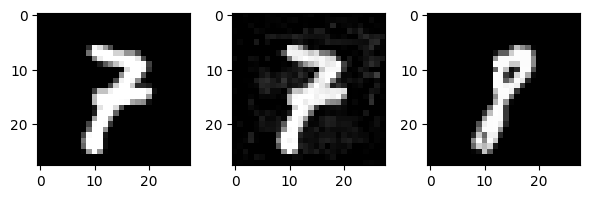

In [ ]:
# visualize one datapoint and counterfactual
if dataset_name =='mnist':
  x_flat = tf.expand_dims(X_train[0], axis=0)
  print(x_flat.shape)
  y_output = model_original.predict(x_flat)
  y_predict = tf.math.argmax(y_output, axis=1)
  y_cf = (y_predict+1) % num_classes

  x_cf1, min_distance = find_counterfactual(model_original, x_flat, y_cf)
  x_cf2, min_distance = find_nearest_neighbor_counterfactual(model_original, x_flat, y_cf, X_train)

  fig, axes = plt.subplots(1, 3, figsize=(6, 4))
  axes[0].imshow(x_flat.numpy().reshape(28, 28), cmap='gray')
  axes[1].imshow(x_cf1.reshape(28, 28), cmap='gray')
  axes[2].imshow(x_cf2.reshape(28, 28), cmap='gray')

  plt.tight_layout()
  plt.show()
  fig.savefig('counterfactual.svg')


In [ ]:
# run single iteration
if dataset_name == 'mnist':
  query_sizes = [50, 100, 150, 200, 250, 300, 350, 400]
if dataset_name == 'iris':
  query_sizes = [10, 20, 30, 40]
if dataset_name == 'wine':
  query_sizes = [10]
# 1 original (no cca)
fidelities_noCCA = try_different_queries(query_sizes, X_train, X_test, use_cca=False, use_Lk=False, cf_method='nearest_neighbor')

# 2 cca only (just soft label)
fidelities_CCA = try_different_queries(query_sizes, X_train, X_test, use_cca=True, use_Lk=False, cf_method='nearest_neighbor')

# 3 cca + modified loss
fidelities_Lk = try_different_queries(query_sizes, X_train, X_test, use_cca=True, use_Lk=True, cf_method='nearest_neighbor')

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 812ms/step - accuracy: 0.1100 - loss: 2.3651
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.2800 - loss: 2.1246
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.3400 - loss: 1.9253
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.4500 - loss: 1.7537
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5800 - loss: 1.6005
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.6400 - loss: 1.4645
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.6900 - loss: 1.3420
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.7400 - loss: 1.2300
Epoch 9/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.7900 - loss: 1.1269
Epoch 10/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.8100 - loss: 1.0312
Epoch 11/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.8000 - loss: 0.9437
Epoch 12/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms

In [ ]:
print(query_sizes)
print(fidelities_noCCA)
print(fidelities_CCA)
print(fidelities_Lk)

[50, 100, 150, 200, 250, 300, 350, 400]
[0.4806666666666667, 0.6501666666666667, 0.7538888888888889, 0.7930555555555555, 0.7953333333333333, 0.8143333333333334, 0.8278888888888889, 0.8393333333333334]
[0.6037222222222223, 0.7170555555555556, 0.7769444444444444, 0.8080555555555555, 0.8218888888888889, 0.8295, 0.8459444444444445, 0.8465555555555555]
[0.5671666666666667, 0.6735, 0.7913888888888889, 0.8077777777777778, 0.8259444444444445, 0.8387777777777777, 0.8457222222222223, 0.8366111111111111]


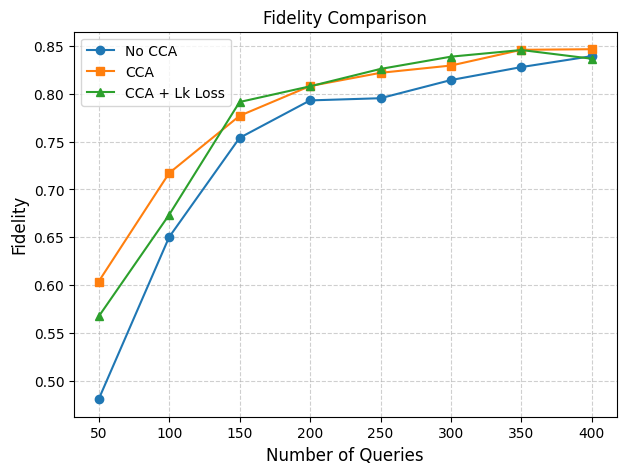

In [ ]:
plt.figure(figsize=(7,5))
plt.plot(query_sizes, fidelities_noCCA, marker='o', label='No CCA')
plt.plot(query_sizes, fidelities_CCA, marker='s', label='CCA')
plt.plot(query_sizes, fidelities_Lk, marker='^', label='CCA + Lk Loss')

plt.xlabel("Number of Queries", fontsize=12)
plt.ylabel("Fidelity", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.title("Fidelity Comparison")
plt.legend()
plt.savefig(dataset_name+'_fidelity_comparison.svg')
plt.show()

In [ ]:
# run multiple iterations
cf_method = 'nearest_neighbor'
iterations = 10
if dataset_name == 'mnist':
  query_sizes = [50, 100, 150, 200, 250, 300, 350, 400]
fidelities_noCCA_iter = try_different_queries_with_iterations(query_sizes, X_train, X_test, use_cca=False, use_Lk=False, iterations=iterations, cf_method=cf_method)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.0900 - loss: 2.3459
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.2500 - loss: 2.1371
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.3400 - loss: 1.9768
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.3800 - loss: 1.8350
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.4500 - loss: 1.7011
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.5300 - loss: 1.5748
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.6200 - loss: 1.4578
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.6800 - loss: 1.3492
Epoch 9/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.6800 - loss: 1.2480
Epoch 10/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.7600 - loss: 1.1541
Epoch 11/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.8000 - loss: 1.0662
Epoch 12/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/

In [ ]:
import pandas as pd
df = pd.DataFrame(fidelities_noCCA_iter)
df.to_csv("fidelities_noCCA_nearest2.csv", index=False)

In [ ]:
fidelities_CCA_iter = try_different_queries_with_iterations(query_sizes, X_train, X_test, use_cca=True, use_Lk=False, iterations=iterations, cf_method=cf_method)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 914ms/step - accuracy: 0.0800 - loss: 2.4081
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.2400 - loss: 2.1528
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.3600 - loss: 1.9500
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.4000 - loss: 1.7816
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.4300 - loss: 1.6349
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.4400 - loss: 1.5023
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.4600 - loss: 1.3817
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.4900 - loss: 1.2731
Epoch 9/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.4900 - loss: 1.1759
Epoch 10/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.4900 - loss: 1.0899
Epoch 11/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.4900 - loss: 1.0130
Epoch 12/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/s

In [ ]:
df = pd.DataFrame(fidelities_CCA_iter)
df.to_csv("fidelities_CCA_nearest2.csv", index=False)

In [ ]:
fidelities_Lk_iter = try_different_queries_with_iterations(query_sizes, X_train, X_test, use_cca=True, use_Lk=True, iterations=iterations, cf_method=cf_method)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.1000 - loss: 2.8504
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.2700 - loss: 2.6089
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.4200 - loss: 2.4138
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.4700 - loss: 2.2462
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.4800 - loss: 2.0979
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.4800 - loss: 1.9651
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.4800 - loss: 1.8453
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.4800 - loss: 1.7384
Epoch 9/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.4900 - loss: 1.6437
Epoch 10/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.5000 - loss: 1.5602
Epoch 11/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.5000 - loss: 1.4865
Epoch 12/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/s

In [ ]:
df = pd.DataFrame(fidelities_Lk_iter)
df.to_csv("fidelities_Lk_nearest2.csv", index=False)